In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data").is_dir():
    PROJECT_DIR = PROJECT_DIR.parent
DATA_DIR = PROJECT_DIR / "data"
FIGURES_DIR = PROJECT_DIR / "assets" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


PUBLICATION_FONT = "Nimbus Sans"
PUBLICATION_FONT_STACK = [
    PUBLICATION_FONT,
    "Arial",
    "Helvetica",
    "DejaVu Sans",
    "Liberation Sans",
    "sans-serif",
]


PLOT_STYLE = {
    "font.family": "sans-serif",
    "font.sans-serif": PUBLICATION_FONT_STACK,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.unicode_minus": False,
}
plt.rcParams.update(PLOT_STYLE)
sns.set_theme(style="whitegrid", font=PUBLICATION_FONT, rc=PLOT_STYLE)


In [2]:
# Prepare the retained genomes used by the treemap.
figure1_tax_levels = ["domain", "phylum", "class", "order", "family", "genus", "species"]
figure1_rank_columns = {level: f"{level}_2026_09_01" for level in figure1_tax_levels}
figure1_genomes = pd.read_parquet(DATA_DIR / "genome_tax_metadata.parquet")
figure1_genomes = figure1_genomes.loc[
    figure1_genomes["qc"].eq("pass")
].rename(columns={column: level for level, column in figure1_rank_columns.items()})
for col in figure1_genomes.select_dtypes(include="object"):
    figure1_genomes[col] = figure1_genomes[col].str.strip()

figure1_treemap_threshold = 50
figure1_binned_genomes = figure1_genomes.copy()
for level in figure1_tax_levels:
    figure1_binned_genomes[level] = figure1_binned_genomes[level].fillna(f"{level}_unresolved")
    low_count = figure1_binned_genomes[level].value_counts()
    low_count = low_count[low_count <= figure1_treemap_threshold].index
    figure1_binned_genomes[level] = figure1_binned_genomes[level].replace(low_count, f"{level}_other")


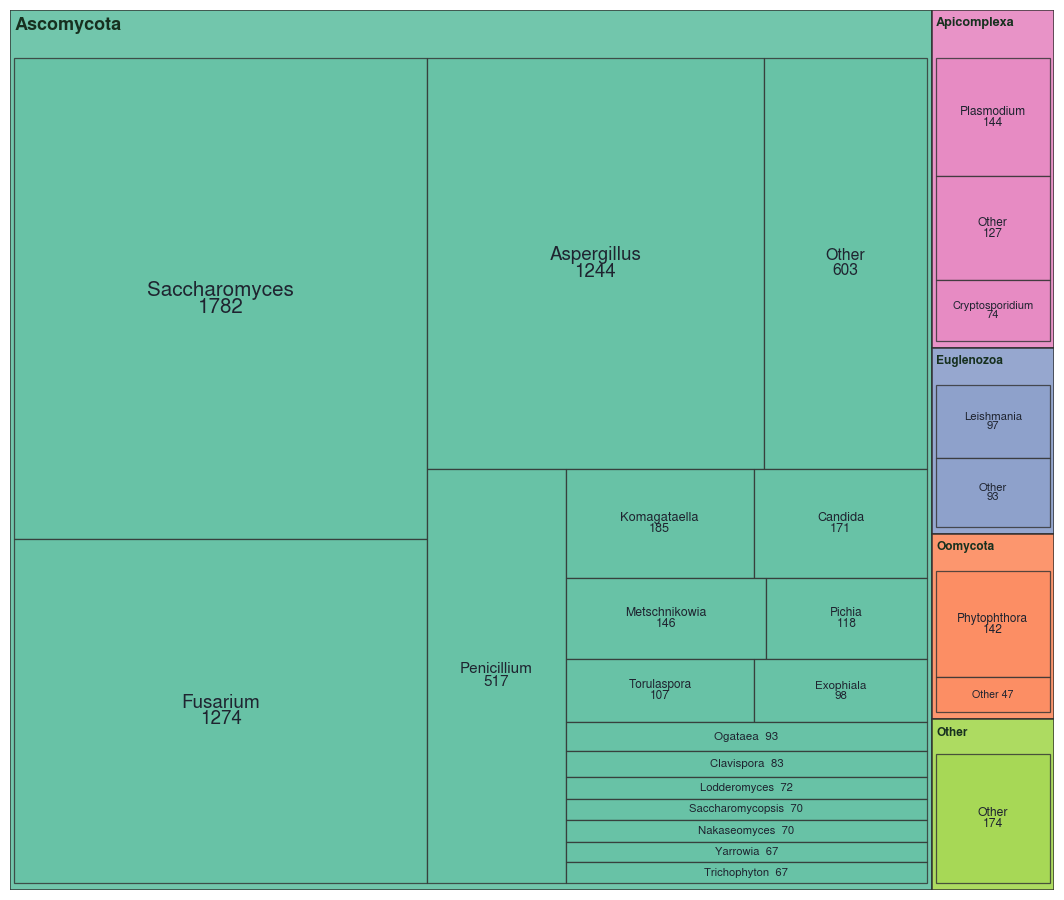

In [3]:
# Treemap plot
from matplotlib.colors import to_rgb
from matplotlib.patches import Rectangle

FIG1_SET2 = ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f", "#e5c494", "#b3b3b3"]


def figure1_squarify(items, x, y, dx, dy):
    items = [item.copy() for item in items if item["value"] > 0]
    total = sum(item["value"] for item in items)
    if not items or total <= 0 or dx <= 0 or dy <= 0:
        return []
    area = dx * dy
    for item in items:
        item["area"] = item["value"] * area / total

    def worst_ratio(row, side):
        if not row:
            return float("inf")
        row_area = sum(item["area"] for item in row)
        max_area = max(item["area"] for item in row)
        min_area = min(item["area"] for item in row)
        if min_area <= 0 or row_area <= 0 or side <= 0:
            return float("inf")
        return max((side**2 * max_area) / (row_area**2), (row_area**2) / (side**2 * min_area))

    def layout_row(row, x, y, dx, dy):
        rects = []
        row_area = sum(item["area"] for item in row)
        if dx >= dy:
            row_h = row_area / dx
            cursor = x
            for item in row:
                rect_w = item["area"] / row_h
                rects.append({**item, "x": cursor, "y": y, "dx": rect_w, "dy": row_h})
                cursor += rect_w
            return rects, x, y + row_h, dx, dy - row_h
        row_w = row_area / dy
        cursor = y
        for item in row:
            rect_h = item["area"] / row_w
            rects.append({**item, "x": x, "y": cursor, "dx": row_w, "dy": rect_h})
            cursor += rect_h
        return rects, x + row_w, y, dx - row_w, dy

    remaining = items[:]
    row = []
    rects = []
    while remaining:
        candidate = remaining[0]
        side = min(dx, dy)
        if not row or worst_ratio(row + [candidate], side) <= worst_ratio(row, side):
            row.append(candidate)
            remaining.pop(0)
        else:
            laid_out, x, y, dx, dy = layout_row(row, x, y, dx, dy)
            rects.extend(laid_out)
            row = []
    if row:
        laid_out, x, y, dx, dy = layout_row(row, x, y, dx, dy)
        rects.extend(laid_out)
    return rects


def figure1_luminance(color):
    r, g, b = to_rgb(color)
    return 0.299 * r + 0.587 * g + 0.114 * b


def figure1_draw_text(ax, patch, x, y, text, fontsize, color="#223", weight="normal"):
    txt = ax.text(x, y, text, fontsize=fontsize, color=color, va="top", ha="left", weight=weight, clip_on=True)
    txt.set_clip_path(patch)
    return txt


def figure1_draw_fitted_label(ax, patch, rect, label, value, max_fontsize, color="#1f2430"):
    renderer = ax.figure.canvas.get_renderer()
    patch_box = patch.get_window_extent(renderer=renderer)
    usable_width = max(patch_box.width - 8, 0)
    usable_height = max(patch_box.height - 8, 0)

    if label.endswith("_other"):
        separator = "\n" if usable_height >= 30 else " "
        text, rotation = f"Other{separator}{value}", 0
    elif usable_height < 30:
        text, rotation = f"{label}  {value}", 0
    else:
        text, rotation = f"{label}\n{value}", 0

    txt = ax.text(
        rect["x"] + rect["dx"] / 2,
        rect["y"] + rect["dy"] / 2,
        text,
        color=color,
        ha="center",
        va="center",
        rotation=rotation,
        linespacing=0.9,
        clip_on=True,
    )
    txt.set_clip_path(patch)
    for font_size in np.arange(max_fontsize, 4.4, -0.5):
        txt.set_fontsize(font_size)
        text_box = txt.get_window_extent(renderer=renderer)
        if text_box.width <= usable_width and text_box.height <= usable_height:
            return txt
    txt.remove()
    return None


def figure1_top_level_rects(phylum_counts, width=1.0, height=1.0):
    counts = phylum_counts.sort_values(ascending=False)
    total = counts.sum()
    largest = counts.index[0]
    largest_width = counts.iloc[0] / total
    rects = [{"label": largest, "value": counts.iloc[0], "x": 0, "y": 0, "dx": width * largest_width, "dy": height}]
    remaining = counts.iloc[1:]
    y_cursor = 0
    x_right = width * largest_width
    dx_right = width - x_right
    remaining_total = remaining.sum()
    for label, value in remaining.items():
        rect_h = height * value / remaining_total
        rects.append({"label": label, "value": value, "x": x_right, "y": y_cursor, "dx": dx_right, "dy": rect_h})
        y_cursor += rect_h
    return rects


def figure1_split_vertical(items, x, y, dx, dy):
    total = sum(item["value"] for item in items)
    rects = []
    cursor = y
    for item in items:
        rect_h = dy * item["value"] / total
        rects.append({**item, "x": x, "y": cursor, "dx": dx, "dy": rect_h})
        cursor += rect_h
    return rects


def figure1_split_horizontal(items, x, y, dx, dy):
    total = sum(item["value"] for item in items)
    rects = []
    cursor = x
    for item in items:
        rect_w = dx * item["value"] / total
        rects.append({**item, "x": cursor, "y": y, "dx": rect_w, "dy": dy})
        cursor += rect_w
    return rects


def figure1_child_rects(phylum, genus_counts, x, y, dx, dy):
    counts = genus_counts.sort_values(ascending=False)
    items = [{"label": genus, "value": int(value)} for genus, value in counts.items()]
    values = {item["label"]: item["value"] for item in items}

    if dx < 0.35 and len(items) > 1:
        return figure1_split_vertical(items, x, y, dx, dy)

    if phylum == "Ascomycota" and {"Saccharomyces", "Fusarium", "Aspergillus", "genus_other", "Penicillium"}.issubset(values):
        rects = []
        left_items = [
            {"label": "Saccharomyces", "value": values["Saccharomyces"]},
            {"label": "Fusarium", "value": values["Fusarium"]},
        ]
        left_value = sum(item["value"] for item in left_items)
        total_value = sum(values.values())
        left_dx = dx * left_value / total_value
        rects.extend(figure1_split_vertical(left_items, x, y, left_dx, dy))

        right_x = x + left_dx
        right_dx = dx - left_dx
        right_total = total_value - left_value
        top_items = [
            {"label": "Aspergillus", "value": values["Aspergillus"]},
            {"label": "genus_other", "value": values["genus_other"]},
        ]
        top_value = sum(item["value"] for item in top_items)
        top_dy = dy * top_value / right_total
        rects.extend(figure1_split_horizontal(top_items, right_x, y, right_dx, top_dy))

        bottom_y = y + top_dy
        bottom_dy = dy - top_dy
        bottom_labels = [item["label"] for item in items if item["label"] not in {"Saccharomyces", "Fusarium", "Aspergillus", "genus_other"}]
        bottom_total = sum(values[label] for label in bottom_labels)
        pen_dx = right_dx * values["Penicillium"] / bottom_total
        rects.append({"label": "Penicillium", "value": values["Penicillium"], "x": right_x, "y": bottom_y, "dx": pen_dx, "dy": bottom_dy})

        small_labels = [label for label in bottom_labels if label != "Penicillium"]
        small_items = [{"label": label, "value": values[label]} for label in small_labels]
        rects.extend(figure1_squarify(small_items, right_x + pen_dx, bottom_y, right_dx - pen_dx, bottom_dy))
        return rects

    if len(items) == 1:
        return [{**items[0], "x": x, "y": y, "dx": dx, "dy": dy}]
    if len(items) == 2:
        if phylum in {"Apicomplexa", "Oomycota"} or dx < dy:
            return figure1_split_vertical(items, x, y, dx, dy)
        return figure1_split_horizontal(items, x, y, dx, dy)
    return figure1_squarify(items, x, y, dx, dy)


def plot_figure1_treemap(ax, binned_genomes):
    unique_phyla = list(binned_genomes["phylum"].drop_duplicates())
    phylum_colors = {phy: FIG1_SET2[i % len(FIG1_SET2)] for i, phy in enumerate(unique_phyla)}
    phylum_counts = binned_genomes["phylum"].value_counts()
    treemap_width = 1.92
    treemap_height = 1.0
    treemap_area = treemap_width * treemap_height
    padding = 0.008

    ax.set_xlim(0, treemap_width)
    ax.set_ylim(treemap_height, 0)
    ax.axis("off")

    for phylum_rect in figure1_top_level_rects(phylum_counts, width=treemap_width, height=treemap_height):
        phylum = phylum_rect["label"]
        color = phylum_colors[phylum]
        parent_patch = Rectangle(
            (phylum_rect["x"], phylum_rect["y"]),
            phylum_rect["dx"],
            phylum_rect["dy"],
            facecolor=color,
            edgecolor="0.18",
            linewidth=1.1,
            alpha=0.92,
        )
        ax.add_patch(parent_patch)
        phylum_area_frac = (phylum_rect["dx"] * phylum_rect["dy"]) / treemap_area
        figure1_draw_text(
            ax,
            parent_patch,
            phylum_rect["x"] + padding,
            phylum_rect["y"] + padding,
            "Other" if str(phylum).endswith("_other") else str(phylum),
            fontsize=max(8, min(13, 7 + 10 * np.sqrt(phylum_area_frac))),
            color="#17301f" if figure1_luminance(color) > 0.58 else "white",
            weight="bold",
        )

        header_h = min(0.055, phylum_rect["dy"] * 0.20)
        inner_x = phylum_rect["x"] + padding
        inner_y = phylum_rect["y"] + header_h
        inner_dx = max(phylum_rect["dx"] - 2 * padding, 0)
        inner_dy = max(phylum_rect["dy"] - header_h - padding, 0)
        genus_counts = binned_genomes.loc[binned_genomes["phylum"] == phylum, "genus"].value_counts().sort_values(ascending=False)

        for genus_rect in figure1_child_rects(phylum, genus_counts, inner_x, inner_y, inner_dx, inner_dy):
            child_patch = Rectangle(
                (genus_rect["x"], genus_rect["y"]),
                genus_rect["dx"],
                genus_rect["dy"],
                facecolor=color,
                edgecolor="0.20",
                linewidth=0.9,
                alpha=0.82,
            )
            ax.add_patch(child_patch)
            rect_area_frac = (genus_rect["dx"] * genus_rect["dy"]) / treemap_area
            if rect_area_frac >= 0.004:
                font_size = float(np.clip(6.5 + 18 * np.sqrt(rect_area_frac), 7, 15))
                label = str(genus_rect["label"])
                figure1_draw_fitted_label(
                    ax,
                    child_patch,
                    genus_rect,
                    label,
                    genus_rect["value"],
                    max_fontsize=font_size,
                    color="#1f2430",
                )


fig, ax_tree = plt.subplots(figsize=(12, 10))
fig.subplots_adjust(left=0.105, right=0.975, top=0.955, bottom=0.075)
fig.canvas.draw()
plot_figure1_treemap(ax_tree, figure1_binned_genomes)
fig.savefig(FIGURES_DIR / "treemap.svg", format="svg", bbox_inches="tight", metadata={"Date": None})
fig.savefig(FIGURES_DIR / "treemap.png", dpi=300, bbox_inches="tight")
plt.show()
